# Entrenamiento de modelo de predicción de categoría


## Importación de librerias necesarias


In [151]:
%load_ext IPython.extensions.autoreload
%autoreload 2


The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [152]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [153]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


In [154]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


In [155]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark

INFO:SparkCreator:[SparkUtils] Stopping existing SparkSession...
INFO:SparkCreator:Starts creating environment
INFO:SparkCreator:Ends creating environment


## Cargar datos fuente de entrenamiento


In [156]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [157]:
REGENERATE_MODEL = True


In [158]:
src_dir_category_prediction = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_category_prediction"

In [159]:
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

In [160]:
TRACKING_URI = "file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow"

In [161]:
from src.utils.models import CategoryPredictionModel

category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', METASTORE_PATH, tracking_uri=TRACKING_URI,
    num_classes=len(categories)
)

category_prediction_model.prepare_data(
    spark, src_dir_category_prediction, target_columns=categories, shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)

train_dataset (TensorSpec(shape=(None, 150), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))
val_dataset (TensorSpec(shape=(None, 150), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))
test_dataset (TensorSpec(shape=(None, 150), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))


## Crear modelo de predicción


In [162]:
category_prediction_model.create_model()
category_prediction_model.model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 256)            │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,721 (327.04 KB)

 Trainable params: 82,953 (324.04 KB)

 Non-trainable params: 768 (3.00 KB)

In [163]:
if REGENERATE_MODEL:
    history_model_category_prediction = category_prediction_model.train(epochs=50)

Epoch 1/50
    237/Unknown 17s 33ms/step - accuracy: 0.1359 - loss: 2.3203

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.12014, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/model_checkpoints/rating_model_epoch_01.h5


2025-10-26 15:51:36.577407: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 3394885126531715367
2025-10-26 15:51:36.577444: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 14368970283424476958


237/237 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.1433 - loss: 2.2486 - val_accuracy: 0.1201 - val_loss: 2.1808 - learning_rate: 0.0010
Epoch 2/50
232/237 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1996 - loss: 2.1390
Epoch 2: val_accuracy improved from 0.12014 to 0.21170, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/model_checkpoints/rating_model_epoch_02.h5


...

2025-10-26 16:02:08.076865: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 3394885126531715367
2025-10-26 16:02:08.076900: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 14368970283424476958


232/237 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4754 - loss: 1.4988
Epoch 49: val_accuracy did not improve from 0.30749
237/237 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.4559 - loss: 1.5446 - val_accuracy: 0.3054 - val_loss: 1.9672 - learning_rate: 8.1000e-06
Epoch 50/50


2025-10-26 16:02:21.262264: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 3394885126531715367
2025-10-26 16:02:21.262301: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 14368970283424476958


232/237 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4782 - loss: 1.5001
Epoch 50: val_accuracy did not improve from 0.30749
237/237 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.4594 - loss: 1.5397 - val_accuracy: 0.3048 - val_loss: 1.9672 - learning_rate: 8.1000e-06
Restoring model weights from the end of the best epoch: 38.


2025-10-26 16:02:34.481538: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 3394885126531715367
2025-10-26 16:02:34.481575: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 14368970283424476958


2025/10/26 16:02:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/26 16:02:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/26 16:02:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Experimento 9eb90a62116b4b86b5c6b63ad7aa9240
3781 3781
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/category_prediction_model/confusion_matrix.png
Error logging confusion matrix to MLflow: Could not find experiment with ID 0


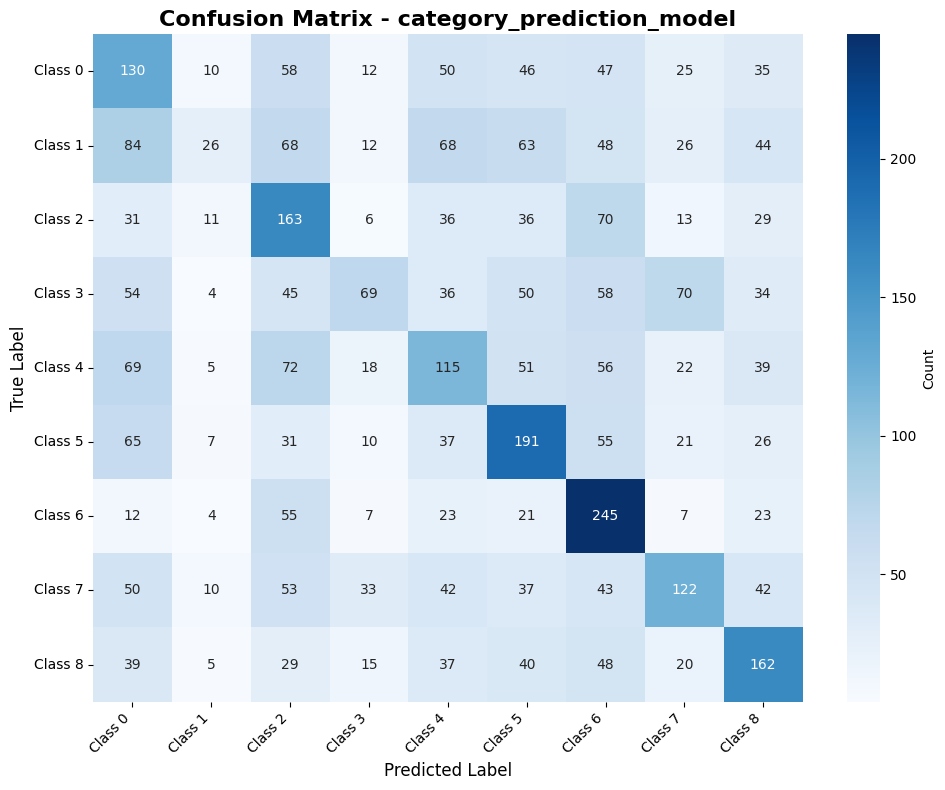

Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_category_prediction_model.png


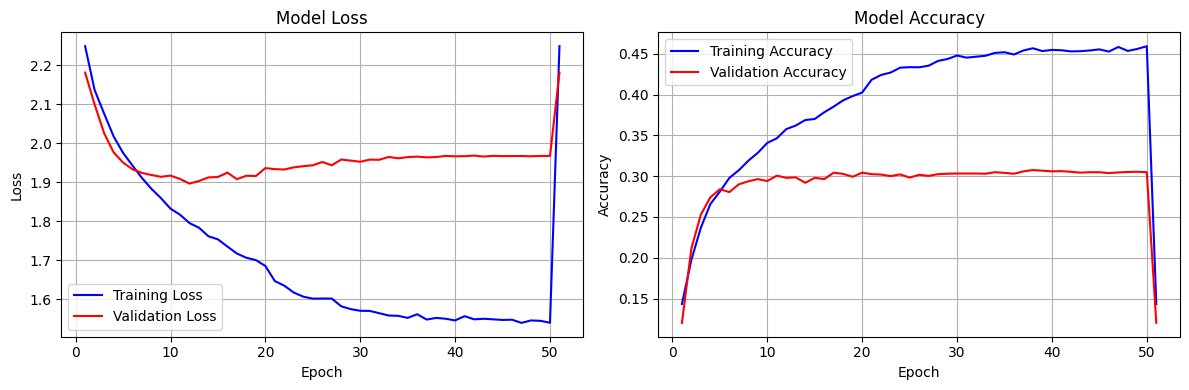

In [164]:
if REGENERATE_MODEL:
    for name, model in [
        ("category_prediction_model", category_prediction_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print("Experimento", exp)

        category_prediction_model.plot_confusion_matrix()

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [165]:
from src.utils.models import CategoryPredictionModel

categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

category_prediction_model = CategoryPredictionModel('category_prediction_model', METASTORE_PATH, num_classes=len(categories), tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
category_prediction_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
